# Features Analysis — CircuitNet-N28

This notebook performs a data-driven analysis of the **input features** of the CircuitNet-N28 dataset and uses the results to validate NIID-Bench partitioning strategy choices.

No label or violation information is used anywhere in this notebook.

## Structure

| Section | Content |
|---------|--------|
| A | Design parameter distributions (metadata parsed from filenames) |
| B | Feature channel statistics extraction (9 input channels) |
| C | Per-channel distribution and inter-channel correlation |
| D | Feature–metadata correlation (which design knobs drive feature variation?) |
| E | Feature space structure (PCA + design-parameter coloring) |
| F | NIID-Bench partitioning validation — IID, Noise, Synthetic |
| G | Summary: data-driven partitioning recommendations |

## Feature channels

Channels follow the 9-channel RouteNet input order:

| # | Channel name |
|---|--------------|
| 0 | macro_region |
| 1 | cell_density |
| 2 | RUDY_long |
| 3 | RUDY_short |
| 4 | RUDY_pin_long |
| 5 | congestion_eGR_H |
| 6 | congestion_eGR_V |
| 7 | congestion_GR_H |
| 8 | congestion_GR_V |

In [7]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
from scipy import stats as scipy_stats
from scipy.stats import wasserstein_distance, ks_2samp, f_oneway
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 11,
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5',
    'figure.facecolor': 'white',
})

sys.path.insert(0, os.path.abspath('.'))
from partitioning import (
    IIDPartitioner,
    NoiseFeaturePartitioner,
    SyntheticFeaturePartitioner,
)

FEATURE_DIR = '../drc_prediction/training_set/DRC/feature/'
N_CHANNELS  = 9
CHANNEL_NAMES = [
    'macro_region', 'cell_density',
    'RUDY_long', 'RUDY_short', 'RUDY_pin_long',
    'congestion_eGR_H', 'congestion_eGR_V',
    'congestion_GR_H',  'congestion_GR_V',
]
print('Imports OK.')

Imports OK.


## Filename Parsing and Metadata Loading

In [ ]:
def parse_sample_name(filename: str) -> dict:
    """Parse a CircuitNet-N28 filename into its design-space components.

    Anchors from the right: the last 5 tokens always carry the prefixes
    c/u/m/p/f; the token at position -6 is macro_count; everything before
    that (after stripping any leading numeric id) is joined as the design name.

    Handles any number of hyphen-separated name parts, including:
      RISCY-a-1-c2-u0.7-m1-p1-f0.npy       → design=RISCY-a
      1-RISCY-a-1-c2-u0.7-m1-p1-f0.npy     → design=RISCY-a  (prefixed)
      zero-riscy-b-1-c2-u0.7-m1-p1-f0.npy  → design=zero-riscy-b
    """
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    # Strip leading numeric id if present (e.g. '1-RISCY-a-...')
    if parts[0].isdigit():
        parts = parts[1:]
    # Need at least: ≥1 design token + macro_count + c + u + m + p + f = 7
    if len(parts) < 7:
        raise ValueError(f'Cannot parse (too few tokens): {filename}')
    # Validate the 5 right-anchored suffix fields in order c, u, m, p, f
    for expected, token in zip(['c', 'u', 'm', 'p', 'f'], parts[-5:]):
        if not token.startswith(expected):
            raise ValueError(
                f'Cannot parse {filename}: expected prefix "{expected}", got "{token}"'
            )
    clock_str, util_str, macro_placement_raw, power_mesh_raw, filler_raw = parts[-5:]
    macro_count = parts[-6]
    design_name = '-'.join(parts[:-6])
    if not design_name:
        raise ValueError(f'Cannot parse {filename}: empty design name')
    return {
        'design_name':      design_name,
        'macro_count':      macro_count,
        'clock_ns':         float(clock_str[1:]),
        'utilization':      float(util_str[1:]),
        'macro_placement':  macro_placement_raw[1:],
        'power_mesh':       power_mesh_raw[1:],
        'filler_insertion': filler_raw[1:],
        'filename':         filename,
    }


feature_exists = os.path.isdir(FEATURE_DIR)
files = sorted(f for f in os.listdir(FEATURE_DIR) if f.endswith('.npy'))
print(f'Feature directory found: {len(files)} .npy files.')
records = []
for fname in files:
    try:
        records.append(parse_sample_name(fname))
    except Exception as e:
        print(f'  Skip {fname}: {e}')
df_meta = pd.DataFrame(records)

print(f'Samples: {len(df_meta)}')
print(df_meta.head())
print(df_meta.dtypes)

df_meta.loc[df_meta['macro_placement'].isin(['1','2','3','4']) == False, 'macro_placement'] = 1
df_meta['macro_placement'] = df_meta['macro_placement'].astype(int)

Feature directory found: 10242 .npy files.
Source: real  |  Samples: 10242
    design_name macro_count  clock_ns  utilization macro_placement power_mesh  \
0       RISCY-a           1       2.0         0.70               1          1   
1       RISCY-a           1       2.0         0.70               2          2   
2       RISCY-a           1       2.0         0.85               2          3   
3       RISCY-a           2       5.0         0.75               2          1   
4  zero-riscy-b           3       2.0         0.85               1          6   

  filler_insertion                                    filename  
0                0            1-RISCY-a-1-c2-u0.7-m1-p1-f0.npy  
1                0           10-RISCY-a-1-c2-u0.7-m2-p2-f0.npy  
2                0         100-RISCY-a-1-c2-u0.85-m2-p3-f0.npy  
3                0        1000-RISCY-a-2-c5-u0.75-m2-p1-f0.npy  
4                1  10000-zero-riscy-b-3-c2-u0.85-m1-p6-f1.npy  
design_name          object
macro_count         

---
## Section A — Design Parameter Distributions

Understand the design space before looking at feature values. These parameters
directly control routing difficulty and are the natural axes for feature-based partitioning.

In [31]:
CAT_COLS = ['design_name','macro_count','macro_placement','power_mesh','filler_insertion']
NUM_COLS = ['utilization','clock_ns']

print('=== Categorical parameter distributions ===')
for col in CAT_COLS:
    vc = df_meta[col].value_counts()
    balance = vc.min() / vc.max()
    print(f'\n{col}  (unique={vc.shape[0]}, balance={balance:.3f}):')
    print(vc.to_string())

print('\n=== Numerical parameter distributions ===')
for col in NUM_COLS:
    print(f'\n{col}:')
    print(df_meta[col].describe().to_string())
    print('  Unique values:', sorted(df_meta[col].unique()))


=== Categorical parameter distributions ===

design_name  (unique=6, balance=0.549):
design_name
zero-riscy-a    2042
RISCY-a         2003
RISCY-FPU-a     1969
RISCY-b         1858
RISCY-FPU-b     1248
zero-riscy-b    1122

macro_count  (unique=3, balance=0.800):
macro_count
1    3861
3    3291
2    3090

macro_placement  (unique=4, balance=0.206):
macro_placement
1    3422
2    3165
3    2950
4     705

power_mesh  (unique=8, balance=0.964):
power_mesh
6    1302
5    1298
7    1292
8    1287
1    1273
3    1271
4    1264
2    1255

filler_insertion  (unique=2, balance=0.749):
filler_insertion
1    5857
0    4385

=== Numerical parameter distributions ===

utilization:
count    10242.000000
mean         0.791349
std          0.068329
min          0.700000
25%          0.750000
50%          0.800000
75%          0.850000
max          0.900000
  Unique values: [0.7, 0.75, 0.8, 0.85, 0.9]

clock_ns:
count    10242.00000
mean         8.17809
std          7.39674
min          2.00000
25%   

design_name
macro_count
macro_placement
power_mesh


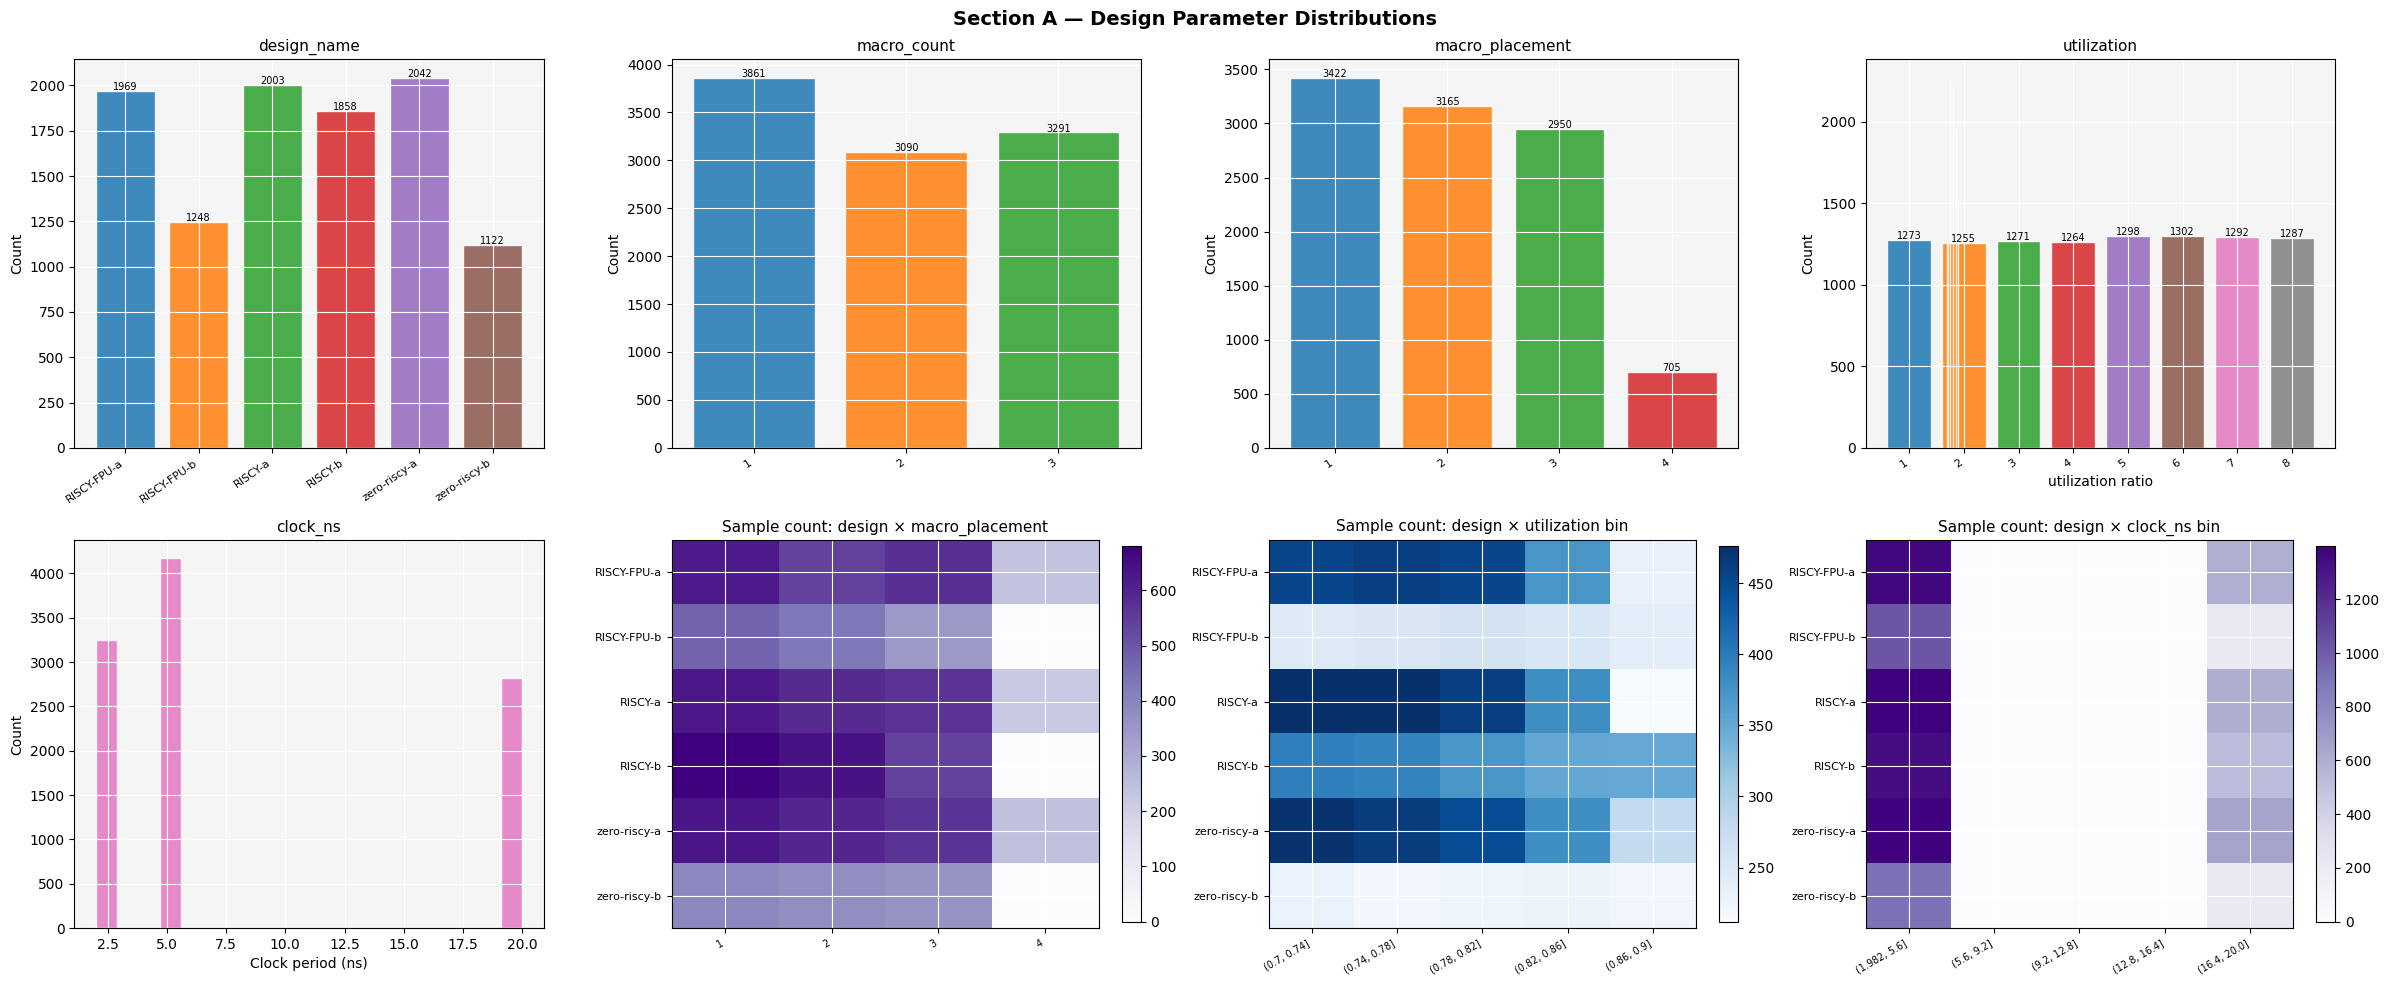

Unique parameter combinations: 10241 / 10242 samples


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle('Section A — Design Parameter Distributions', fontsize=14, fontweight='bold')

cmap10 = mcm.get_cmap('tab10')

for ax, col in zip(axes[0], CAT_COLS):
    vc = df_meta[col].value_counts().sort_index()
    colors = [cmap10(i % 10) for i in range(len(vc))]
    bars = ax.bar(range(len(vc)), vc.values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('Count')
    for bar, cnt in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(cnt), ha='center', fontsize=7)

# Utilization histogram
ax = axes[0][3]
ax.hist(df_meta['utilization'], bins=30, color=cmap10(5), alpha=0.85, edgecolor='white')
ax.set_title('utilization')
ax.set_xlabel('utilization ratio')
ax.set_ylabel('Count')

# Clock histogram
ax = axes[1][0]
ax.hist(df_meta['clock_ns'], bins=20, color=cmap10(6), alpha=0.85, edgecolor='white')
ax.set_title('clock_ns')
ax.set_xlabel('Clock period (ns)')
ax.set_ylabel('Count')

# design x macro_placement
ax = axes[1][1]
pivot2 = df_meta.groupby(['design_name', 'macro_placement']).size().unstack(fill_value=0)
mat2 = pivot2.values.astype(float)
im2 = ax.imshow(mat2, aspect='auto', cmap='Purples')
ax.set_yticks(range(len(pivot2.index)))
ax.set_yticklabels(pivot2.index, fontsize=8)
ax.set_xticks(range(len(pivot2.columns)))
ax.set_xticklabels([str(c) for c in pivot2.columns], rotation=30, ha='right', fontsize=7)
ax.set_title('Sample count: design × macro_placement')
plt.colorbar(im2, ax=ax, fraction=0.04)

# Design × utilization sample counts heatmap
ax = axes[1][2]
util_bins = pd.cut(df_meta['utilization'], bins=5)
pivot = df_meta.groupby(['design_name', util_bins]).size().unstack(fill_value=0)
mat = pivot.values.astype(float)
im = ax.imshow(mat, aspect='auto', cmap='Blues')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], rotation=30, ha='right', fontsize=7)
ax.set_title('Sample count: design × utilization bin')
plt.colorbar(im, ax=ax, fraction=0.04)

# Design × clock sample counts heatmap
ax = axes[1][3]
clock_bins = pd.cut(df_meta['clock_ns'], bins=5)
pivot2 = df_meta.groupby(['design_name', clock_bins]).size().unstack(fill_value=0)
mat2 = pivot2.values.astype(float)
im2 = ax.imshow(mat2, aspect='auto', cmap='Purples')
ax.set_yticks(range(len(pivot2.index)))
ax.set_yticklabels(pivot2.index, fontsize=8)
ax.set_xticks(range(len(pivot2.columns)))
ax.set_xticklabels([str(c) for c in pivot2.columns], rotation=30, ha='right', fontsize=7)
ax.set_title('Sample count: design × clock_ns bin')
plt.colorbar(im2, ax=ax, fraction=0.04)

plt.tight_layout()
plt.show()

# Design space coverage
all_cols = CAT_COLS + ['clock_ns', 'utilization']
unique_combos = df_meta[all_cols].drop_duplicates()
print(f'Unique parameter combinations: {len(unique_combos)} / {len(df_meta)} samples')

---
## Section B — Feature Channel Statistics Extraction

For each sample and each of the 9 feature channels compute:
- `mean`: average feature intensity over the 256×256 tile map
- `std`: spatial standard deviation (captures local variation)
- `max`: peak value (relevant for congestion hotspots)
- `p95`: 95th spatial percentile (robust extreme)

This produces a compact **36-dimensional feature statistics vector** per sample,  
used in all subsequent sections without loading full arrays into memory.

In [33]:
STATS = ['mean', 'std', 'max', 'p95']
FEAT_COLS = [f'{ch}_{stat}' for ch in CHANNEL_NAMES for stat in STATS]


def extract_channel_stats(arr: np.ndarray) -> np.ndarray:
    """Extract [mean, std, max, p95] for each channel of a (H, W, C) or (C, H, W) array."""
    if arr.ndim == 3 and arr.shape[-1] == N_CHANNELS:
        channels = [arr[:, :, c].ravel() for c in range(N_CHANNELS)]
    elif arr.ndim == 3 and arr.shape[0] == N_CHANNELS:
        channels = [arr[c].ravel() for c in range(N_CHANNELS)]
    else:
        raise ValueError(f'Unexpected shape {arr.shape} for {N_CHANNELS}-channel feature')
    row = []
    for ch in channels:
        row.extend([float(ch.mean()), float(ch.std()),
                    float(ch.max()), float(np.percentile(ch, 95))])
    return np.array(row, dtype=np.float32)

print(f'Extracting statistics from {len(df_meta)} feature files...')
stat_rows = []
failed = 0
for fname in df_meta['filename']:
    fpath = os.path.join(FEATURE_DIR, fname)
    try:
        arr = np.load(fpath)
        stat_rows.append(extract_channel_stats(arr))
    except Exception as e:
        stat_rows.append(np.full(len(FEAT_COLS), np.nan, dtype=np.float32))
        failed += 1
df_stats = pd.DataFrame(stat_rows, columns=FEAT_COLS)
df = pd.concat([df_meta.reset_index(drop=True), df_stats], axis=1)
df = df.dropna(subset=FEAT_COLS).reset_index(drop=True)
print(f'Done. {len(df)} / {len(df_meta)} samples loaded successfully ({failed} failed).')

print(f'\nFeature statistics shape: {df[FEAT_COLS].shape}')
print(df[FEAT_COLS].describe().round(4).to_string())

Extracting statistics from 10242 feature files...
Done. 10242 / 10242 samples loaded successfully (0 failed).

Feature statistics shape: (10242, 36)
       macro_region_mean  macro_region_std  macro_region_max  macro_region_p95  cell_density_mean  cell_density_std  cell_density_max  cell_density_p95  RUDY_long_mean  RUDY_long_std  RUDY_long_max  RUDY_long_p95  RUDY_short_mean  RUDY_short_std  RUDY_short_max  RUDY_short_p95  RUDY_pin_long_mean  RUDY_pin_long_std  RUDY_pin_long_max  RUDY_pin_long_p95  congestion_eGR_H_mean  congestion_eGR_H_std  congestion_eGR_H_max  congestion_eGR_H_p95  congestion_eGR_V_mean  congestion_eGR_V_std  congestion_eGR_V_max  congestion_eGR_V_p95  congestion_GR_H_mean  congestion_GR_H_std  congestion_GR_H_max  congestion_GR_H_p95  congestion_GR_V_mean  congestion_GR_V_std  congestion_GR_V_max  congestion_GR_V_p95
count         10242.0000        10242.0000           10242.0        10242.0000         10242.0000        10242.0000           10242.0        10242.0

---
## Section C — Per-Channel Distribution and Inter-Channel Correlation

Understand the marginal distribution of each channel's mean and std, and identify
redundant channels (high correlation) vs independent channels.

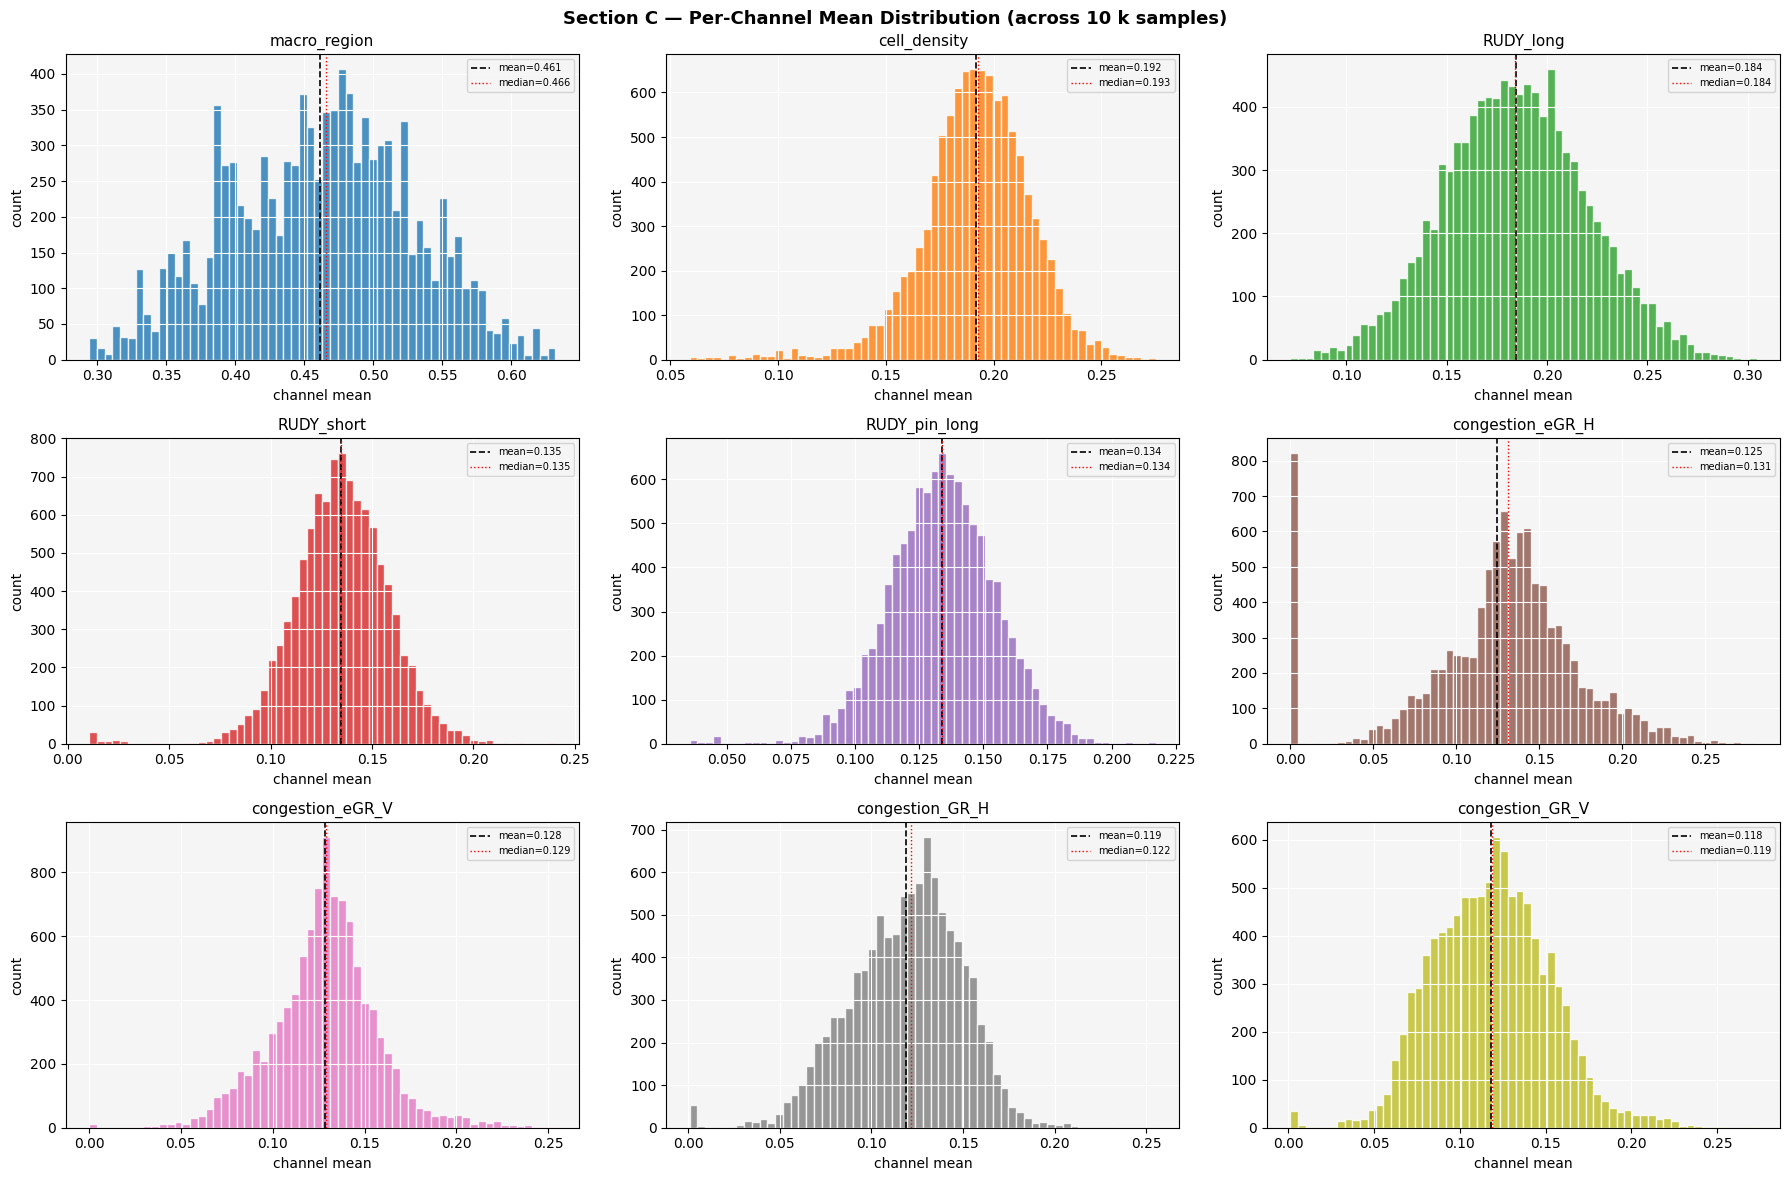

In [34]:
# Distribution of channel *means* across samples
mean_cols = [f'{ch}_mean' for ch in CHANNEL_NAMES]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Section C — Per-Channel Mean Distribution (across 10 k samples)',
             fontsize=13, fontweight='bold')

palette = mcm.get_cmap('tab10')
for ax, col, i in zip(axes.ravel(), mean_cols, range(N_CHANNELS)):
    vals = df[col].values
    ax.hist(vals, bins=60, color=palette(i), alpha=0.8, edgecolor='white')
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.3f}')
    ax.axvline(np.median(vals), color='red', linestyle=':', linewidth=1.0,
               label=f'median={np.median(vals):.3f}')
    ax.set_title(CHANNEL_NAMES[i])
    ax.set_xlabel('channel mean')
    ax.set_ylabel('count')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

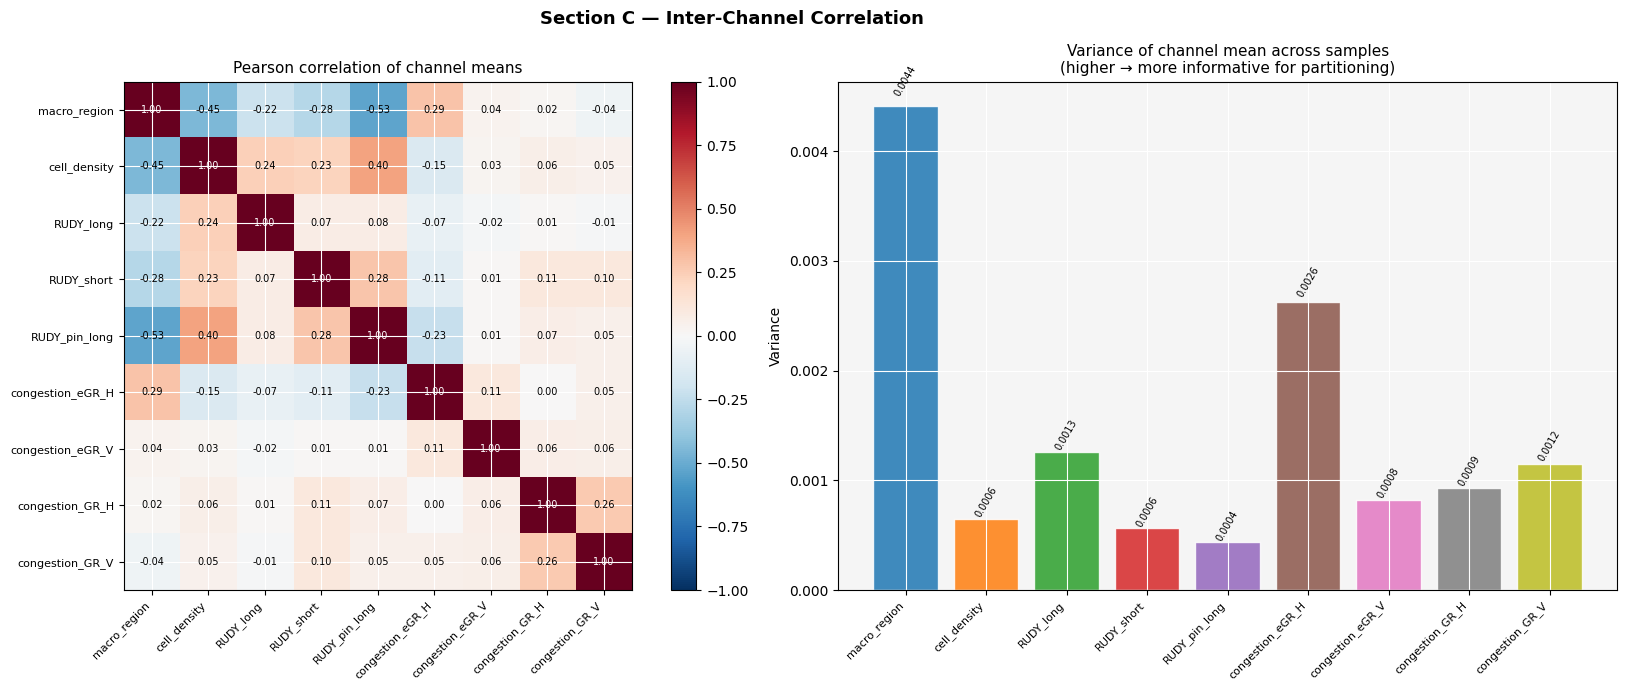

Highly correlated channel pairs (|r| > 0.7):
  None found above |r| = 0.7


In [35]:
# Pearson correlation matrix of the 9 channel means
corr = df[mean_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Section C — Inter-Channel Correlation', fontsize=13, fontweight='bold')

ax = axes[0]
mat = corr.values
im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
for r in range(N_CHANNELS):
    for c in range(N_CHANNELS):
        ax.text(c, r, f'{mat[r,c]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(mat[r,c]) > 0.6 else 'black')
ax.set_xticks(range(N_CHANNELS))
ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(N_CHANNELS))
ax.set_yticklabels(CHANNEL_NAMES, fontsize=8)
ax.set_title('Pearson correlation of channel means')
plt.colorbar(im, ax=ax, fraction=0.04)

# Variance per channel (which channels have most spread across samples?)
ax = axes[1]
channel_var = df[mean_cols].var().values
bars = ax.bar(range(N_CHANNELS), channel_var,
              color=[palette(i) for i in range(N_CHANNELS)], alpha=0.85, edgecolor='white')
ax.set_xticks(range(N_CHANNELS))
ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_title('Variance of channel mean across samples\n(higher → more informative for partitioning)')
ax.set_ylabel('Variance')
for bar, v in zip(bars, channel_var):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f'{v:.4f}', ha='center', fontsize=7, rotation=60)

plt.tight_layout()
plt.show()

# Print highly correlated pairs
print('Highly correlated channel pairs (|r| > 0.7):')
found = False
for i in range(N_CHANNELS):
    for j in range(i+1, N_CHANNELS):
        r = mat[i, j]
        if abs(r) > 0.7:
            print(f'  {CHANNEL_NAMES[i]} ↔ {CHANNEL_NAMES[j]}: r = {r:.3f}')
            found = True
if not found:
    print('  None found above |r| = 0.7')

---
## Section D — Feature–Metadata Correlation

Identify which design knobs (utilization, clock_ns, design_name) are the strongest
predictors of feature channel values.

This directly informs which metadata axes are valid for **Synthetic Feature Partitioning** (NIID-Bench strategy 4):
only axes that strongly predict features create genuine feature-distribution skew between parties.

In [36]:
# Pearson r between each continuous metadata variable and each channel mean
meta_num = ['utilization', 'clock_ns']
print('Pearson r between design parameters and channel means:')
print(f'{"":20s}', end='')
for ch in CHANNEL_NAMES:
    print(f'{ch[:12]:>13s}', end='')
print()

corr_rows = {}
for param in meta_num:
    corr_rows[param] = []
    print(f'{param:20s}', end='')
    for col in mean_cols:
        r, _ = scipy_stats.pearsonr(df[param], df[col])
        corr_rows[param].append(r)
        print(f'{r:>13.3f}', end='')
    print()

# ANOVA F-statistic: does design_name significantly explain each channel?
print('\nOne-way ANOVA F (design_name → channel mean):')
print(f'{"":20s}', end='')
for ch in CHANNEL_NAMES:
    print(f'{ch[:12]:>13s}', end='')
print()

anova_f = []
anova_p = []
print(f'{"design_name (F)":20s}', end='')
for col in mean_cols:
    groups = [df.loc[df['design_name']==d, col].values for d in designs_uniq]
    stat, pval = f_oneway(*groups)
    anova_f.append(stat)
    anova_p.append(pval)
    print(f'{stat:>13.1f}', end='')
print()

print(f'{"design_name (p)":20s}', end='')
for p in anova_p:
    marker = '***' if p < 0.001 else ('*' if p < 0.05 else '  n.s.')
    print(f'{marker:>13s}', end='')
print()

# Eta-squared (effect size for ANOVA)
eta_sq = []
print(f'{"design_name (η²)":20s}', end='')
for col in mean_cols:
    groups = [df.loc[df['design_name']==d, col].values for d in designs_uniq]
    grand_mean = df[col].mean()
    ss_between = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
    ss_total   = sum((df[col].values - grand_mean)**2)
    eta2 = ss_between / ss_total if ss_total > 0 else 0.0
    eta_sq.append(eta2)
    print(f'{eta2:>13.3f}', end='')
print()

print('\nInterpretation: η² > 0.14 → large effect, 0.06-0.14 → medium, < 0.06 → small')

Pearson r between design parameters and channel means:
                     macro_region cell_density    RUDY_long   RUDY_short RUDY_pin_lon congestion_e congestion_e congestion_G congestion_G
utilization                 0.387       -0.239       -0.227       -0.115       -0.181        0.187       -0.001       -0.103       -0.022
clock_ns                   -0.061        0.060       -0.046        0.059        0.080       -0.015       -0.005        0.061        0.103

One-way ANOVA F (design_name → channel mean):
                     macro_region cell_density    RUDY_long   RUDY_short RUDY_pin_lon congestion_e congestion_e congestion_G congestion_G
design_name (F)            2054.6        176.5        250.1        127.7        615.0        550.4         44.6         26.2         30.7
design_name (p)               ***          ***          ***          ***          ***          ***          ***          ***          ***
design_name (η²)            0.501        0.079        0.109        0.0

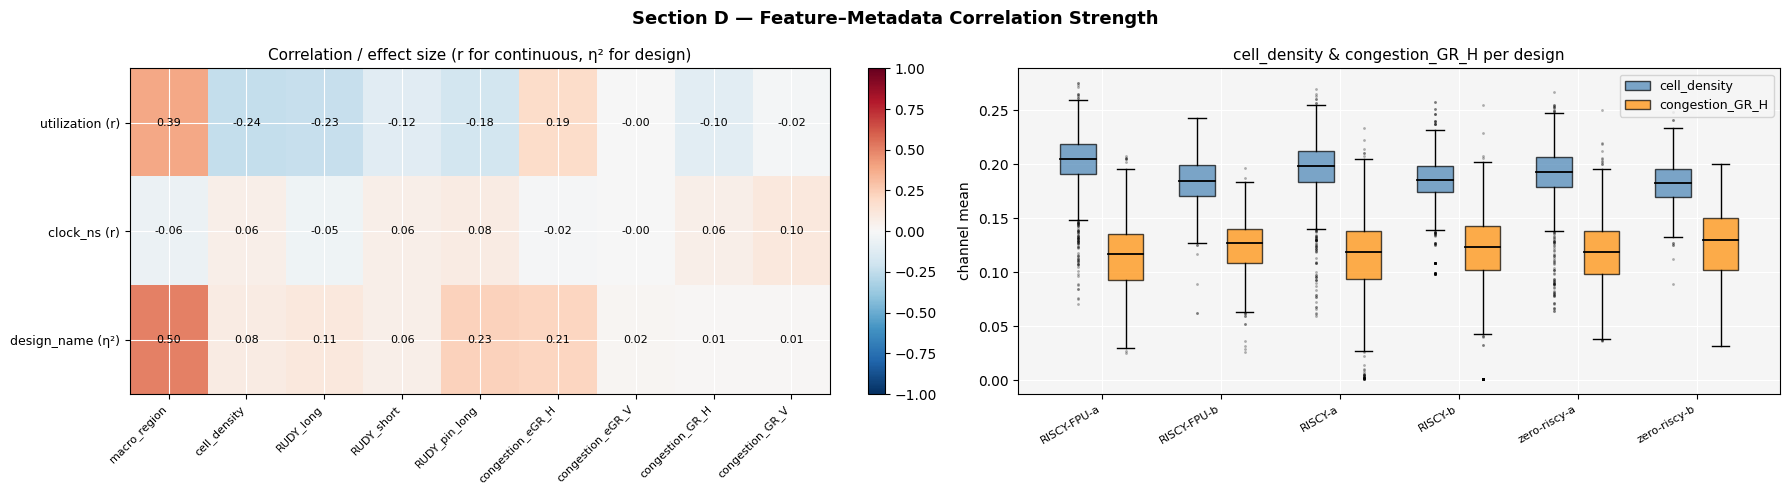

In [37]:
# Heatmap: Pearson r between design params + design_name (as eta^2) and channel means
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Section D — Feature–Metadata Correlation Strength',
             fontsize=13, fontweight='bold')

# Build combined correlation matrix
corr_matrix = np.array(
    [corr_rows['utilization'],
     corr_rows['clock_ns'],
     eta_sq]
)
row_labels = ['utilization (r)', 'clock_ns (r)', 'design_name (η²)']

ax = axes[0]
im = ax.imshow(corr_matrix, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
for r in range(corr_matrix.shape[0]):
    for c in range(N_CHANNELS):
        val = corr_matrix[r, c]
        ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(val) > 0.6 else 'black')
ax.set_xticks(range(N_CHANNELS))
ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(3))
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title('Correlation / effect size (r for continuous, η² for design)')
plt.colorbar(im, ax=ax, fraction=0.03)

# Box plots: cell_density and congestion_GR_H per design
ax = axes[1]
key_channels = ['cell_density_mean', 'congestion_GR_H_mean']
offsets = np.linspace(-0.2, 0.2, len(key_channels))
design_idx = {d: i for i, d in enumerate(designs_uniq)}
colors_key = ['steelblue', 'darkorange']

for j, (col, color) in enumerate(zip(key_channels, colors_key)):
    positions = [design_idx[d] + offsets[j] for d in designs_uniq]
    data = [df.loc[df['design_name']==d, col].values for d in designs_uniq]
    bp = ax.boxplot(data, positions=positions, widths=0.3,
                    patch_artist=True, notch=False,
                    medianprops={'color':'black','linewidth':1.3},
                    flierprops={'marker':'.','markersize':2,'alpha':0.3})
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    bp['boxes'][0].set_label(col.replace('_mean',''))

ax.set_xticks(range(len(designs_uniq)))
ax.set_xticklabels(designs_uniq, rotation=30, ha='right', fontsize=8)
ax.set_title('cell_density & congestion_GR_H per design')
ax.set_ylabel('channel mean')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

R² of (utilization + clock_ns) → channel mean:
macro_region_mean        0.1519
cell_density_mean        0.0600
RUDY_long_mean           0.0544
RUDY_pin_long_mean       0.0384
congestion_eGR_H_mean    0.0350
RUDY_short_mean          0.0163
congestion_GR_H_mean     0.0139
congestion_GR_V_mean     0.0109
congestion_eGR_V_mean    0.0000


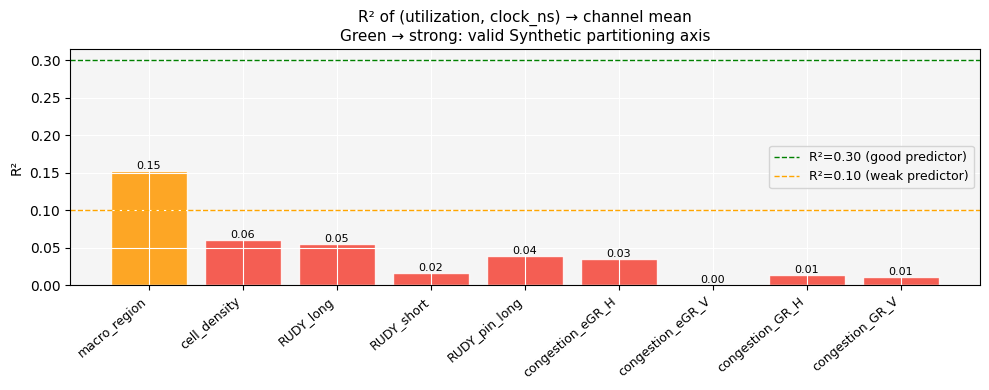

In [38]:
# Which channels are best predicted by utilization and clock_ns?
# Use linear regression R² for a clean summary
from sklearn.linear_model import LinearRegression

X_meta = df[['utilization', 'clock_ns']].values
r2_scores = {}
for col in mean_cols:
    y = df[col].values
    reg = LinearRegression().fit(X_meta, y)
    r2_scores[col] = reg.score(X_meta, y)

r2_series = pd.Series(r2_scores, name='R²')
print('R² of (utilization + clock_ns) → channel mean:')
print(r2_series.sort_values(ascending=False).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors_r2 = ['#4caf50' if v > 0.3 else '#ff9800' if v > 0.1 else '#f44336'
              for v in r2_series.values]
bars = ax.bar(range(len(r2_series)), r2_series.values, color=colors_r2, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(r2_series)))
ax.set_xticklabels([c.replace('_mean','') for c in r2_series.index],
                   rotation=40, ha='right', fontsize=9)
ax.axhline(0.30, color='green',  linestyle='--', linewidth=1, label='R²=0.30 (good predictor)')
ax.axhline(0.10, color='orange', linestyle='--', linewidth=1, label='R²=0.10 (weak predictor)')
ax.set_title('R² of (utilization, clock_ns) → channel mean\n'
             'Green → strong: valid Synthetic partitioning axis')
ax.set_ylabel('R²')
ax.legend(fontsize=9)
for bar, v in zip(bars, r2_series.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{v:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## Section E — Feature Space Structure (PCA)

Project the 36-dimensional feature statistics into 2D/3D with PCA and colour by design parameters.  
Separable clusters → feature-based partitioning creates genuine Non-IID distributions.  
Mixed clusters → partitioning by that axis produces little feature skew.

PCA explained variance ratio:
  PC1: 0.286  (cumulative: 0.286)
  PC2: 0.088  (cumulative: 0.374)
  PC3: 0.084  (cumulative: 0.458)
  PC4: 0.069  (cumulative: 0.527)
  PC5: 0.066  (cumulative: 0.594)
  PC6: 0.062  (cumulative: 0.656)
  PC7: 0.047  (cumulative: 0.703)
  PC8: 0.043  (cumulative: 0.746)
  PC9: 0.038  (cumulative: 0.784)
  PC10: 0.034  (cumulative: 0.818)

PCs needed for 90% variance: 11


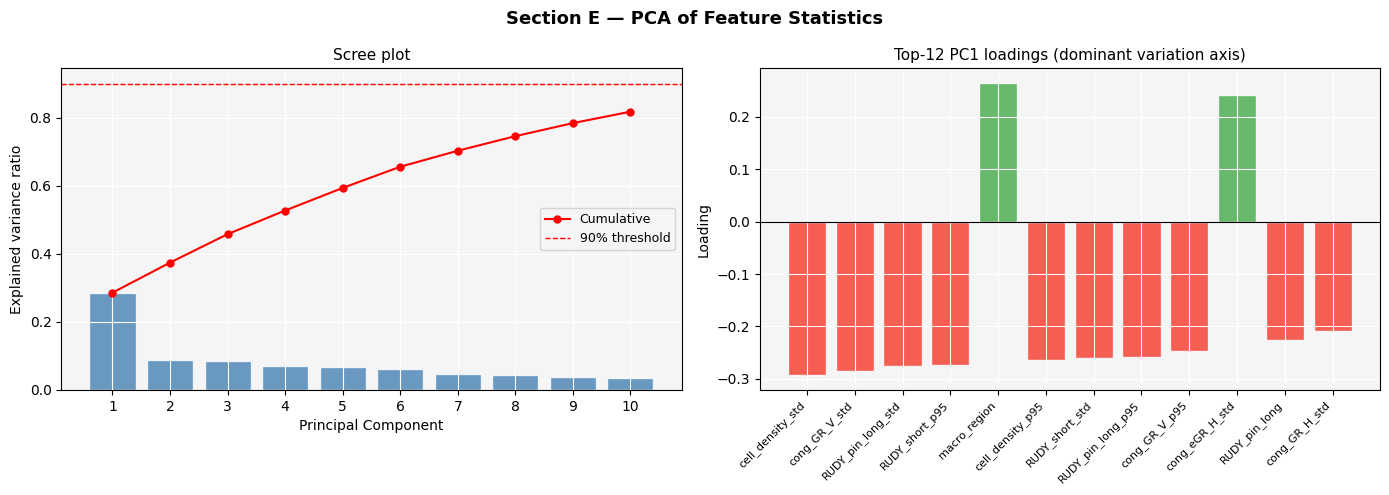

In [39]:
X_raw = df[FEAT_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca = PCA(n_components=min(10, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print('PCA explained variance ratio:')
for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    print(f'  PC{i+1}: {ev:.3f}  (cumulative: {cv:.3f})')

n_for_90 = int(np.searchsorted(cumulative, 0.90)) + 1
print(f'\nPCs needed for 90% variance: {n_for_90}')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section E — PCA of Feature Statistics', fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(range(1, len(explained)+1), explained, color='steelblue', alpha=0.8, edgecolor='white')
ax.plot(range(1, len(cumulative)+1), cumulative, 'ro-', linewidth=1.5, markersize=5,
        label='Cumulative')
ax.axhline(0.90, color='red', linestyle='--', linewidth=1, label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance ratio')
ax.set_title('Scree plot')
ax.legend(fontsize=9)
ax.set_xticks(range(1, len(explained)+1))

# PC1 loadings: which channels contribute most to PC1?
ax = axes[1]
loadings_pc1 = pca.components_[0]
sorted_idx = np.argsort(np.abs(loadings_pc1))[::-1][:12]
colors_load = ['#4caf50' if v > 0 else '#f44336' for v in loadings_pc1[sorted_idx]]
ax.bar(range(12), loadings_pc1[sorted_idx], color=colors_load, alpha=0.85, edgecolor='white')
ax.set_xticks(range(12))
ax.set_xticklabels(
    [FEAT_COLS[i].replace('_mean','').replace('congestion_','cong_') for i in sorted_idx],
    rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Top-12 PC1 loadings (dominant variation axis)')
ax.set_ylabel('Loading')
plt.tight_layout()
plt.show()

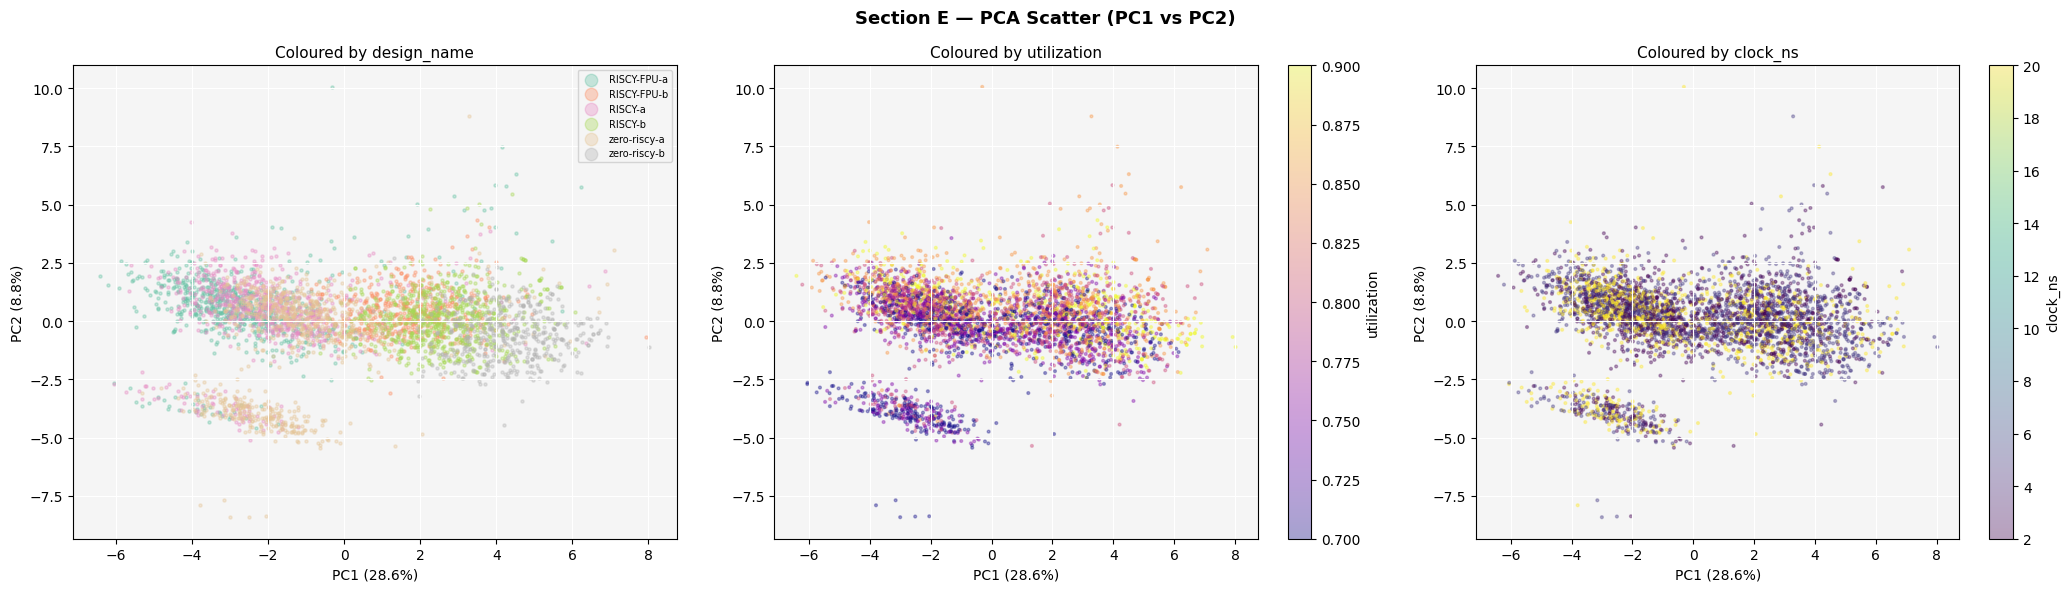

Pearson r(utilization, PC1) = 0.141
Pearson r(clock_ns,    PC1) = -0.086
→ PC1 is mostly driven by: utilization


In [46]:
# PCA scatter coloured by design_name, utilization, clock_ns
N_PLOT = min(4000, len(df))
idx_plot = np.random.default_rng(0).choice(len(df), N_PLOT, replace=False)
X2 = X_pca[idx_plot, :2]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Section E — PCA Scatter (PC1 vs PC2)', fontsize=13, fontweight='bold')

# By design
ax = axes[0]
cmap_d = mcm.get_cmap('Set2', len(designs_uniq))
for i, d in enumerate(designs_uniq):
    mask = df.iloc[idx_plot]['design_name'].values == d
    ax.scatter(X2[mask, 0], X2[mask, 1], s=5, alpha=0.35,
               color=cmap_d(i), label=d)
ax.set_xlabel(f'PC1 ({explained[0]:.1%})')
ax.set_ylabel(f'PC2 ({explained[1]:.1%})')
ax.set_title('Coloured by design_name')
ax.legend(fontsize=7, markerscale=4)

# By utilization
ax = axes[1]
sc = ax.scatter(X2[:, 0], X2[:, 1], s=4, alpha=0.35,
                c=df.iloc[idx_plot]['utilization'].values, cmap='plasma')
plt.colorbar(sc, ax=ax, label='utilization')
ax.set_xlabel(f'PC1 ({explained[0]:.1%})')
ax.set_ylabel(f'PC2 ({explained[1]:.1%})')
ax.set_title('Coloured by utilization')

# By clock_ns
ax = axes[2]
sc = ax.scatter(X2[:, 0], X2[:, 1], s=4, alpha=0.35,
                c=df.iloc[idx_plot]['clock_ns'].values, cmap='viridis')
plt.colorbar(sc, ax=ax, label='clock_ns')
ax.set_xlabel(f'PC1 ({explained[0]:.1%})')
ax.set_ylabel(f'PC2 ({explained[1]:.1%})')
ax.set_title('Coloured by clock_ns')

plt.tight_layout()
plt.show()

# Quantify: how much PC1 variance is explained by utilization alone?
r_util_pc1, _ = scipy_stats.pearsonr(df['utilization'], X_pca[:, 0])
r_clock_pc1, _ = scipy_stats.pearsonr(df['clock_ns'], X_pca[:, 0])
print(f'Pearson r(utilization, PC1) = {r_util_pc1:.3f}')
print(f'Pearson r(clock_ns,    PC1) = {r_clock_pc1:.3f}')
print(f'→ PC1 is mostly driven by: {"utilization" if abs(r_util_pc1) > abs(r_clock_pc1) else "clock_ns"}')

---
## Section F — NIID-Bench Partitioning Validation (Feature-Driven)

We apply three partitioning strategies and measure feature distribution divergence between parties.  
The goal is to answer: **does each strategy actually produce meaningful feature Non-IIDness?**

### Metrics used
- **KS statistic** (Kolmogorov-Smirnov): max difference between CDFs of two samples; 0 = identical, 1 = fully separated
- **Wasserstein distance** (Earth Mover's Distance): average effort to transform one distribution into the other; 0 = identical
- Applied to each feature channel across all pairs of parties

### Strategies
1. **IID** — baseline: all parties should have similar feature distributions (KS ≈ 0)
2. **Noise-based** — IID splits + per-party Gaussian noise; sweep noise_std to quantify distribution shift
3. **Synthetic (grid)** — partition by utilization × clock_ns quantile grid; should produce the largest feature skew

In [47]:
N_PARTIES = 6

# Key channels for validation: choose the two highest-variance channels
# as representatives (one spatial-structure channel, one congestion channel)
channel_var_vals = {ch: df[f'{ch}_mean'].var() for ch in CHANNEL_NAMES}
top2_channels = sorted(channel_var_vals, key=channel_var_vals.get, reverse=True)[:2]
print(f'Highest-variance channels (used as validation proxies): {top2_channels}')


def pairwise_ks_wasserstein(partitions, channels):
    """Compute mean pairwise KS and Wasserstein distance for given channels.

    Returns:
        mean_ks:   mean KS statistic over all party pairs × channels
        mean_wass: mean Wasserstein distance over all party pairs × channels
        per_channel_ks: dict {channel: list of pairwise KS values}
    """
    ks_all, wass_all = [], []
    per_ch_ks = {ch: [] for ch in channels}
    for i in range(len(partitions)):
        for j in range(i+1, len(partitions)):
            for ch in channels:
                col = f'{ch}_mean'
                a = partitions[i][col].dropna().values
                b = partitions[j][col].dropna().values
                if len(a) > 1 and len(b) > 1:
                    ks = ks_2samp(a, b).statistic
                    w  = wasserstein_distance(a, b)
                    ks_all.append(ks)
                    wass_all.append(w)
                    per_ch_ks[ch].append(ks)
    return (float(np.mean(ks_all)) if ks_all else 0.0,
            float(np.mean(wass_all)) if wass_all else 0.0,
            per_ch_ks)


print('Helper functions defined.')

Highest-variance channels (used as validation proxies): ['macro_region', 'congestion_eGR_H']
Helper functions defined.


IID partition sizes: [2114, 2061, 1834, 1520, 1454, 1259]
IID mean pairwise KS:          0.0307
IID mean pairwise Wasserstein: 0.001646


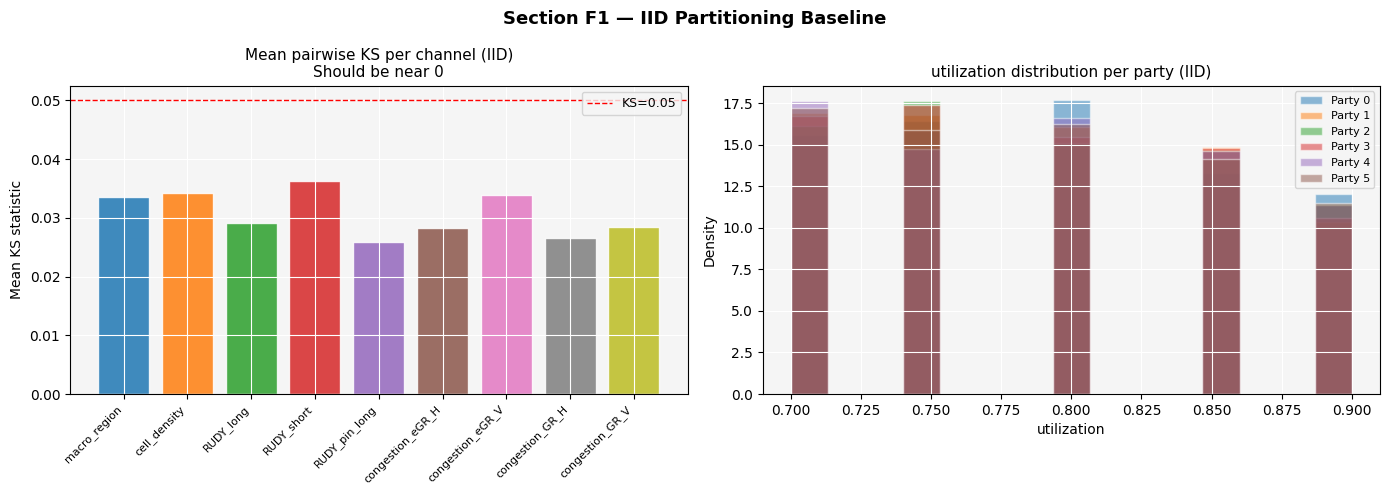

In [48]:
# ---- F1: IID partitioning ----
iid_parts = IIDPartitioner(n_partitions=N_PARTIES, seed=42).partition(df)
iid_sizes = [len(p) for p in iid_parts]
iid_ks, iid_wass, iid_per_ch = pairwise_ks_wasserstein(iid_parts, CHANNEL_NAMES)

print(f'IID partition sizes: {iid_sizes}')
print(f'IID mean pairwise KS:          {iid_ks:.4f}')
print(f'IID mean pairwise Wasserstein: {iid_wass:.6f}')

# KS distribution across channels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section F1 — IID Partitioning Baseline', fontsize=13, fontweight='bold')

ax = axes[0]
ks_per_ch_mean = [np.mean(iid_per_ch[ch]) if iid_per_ch[ch] else 0 for ch in CHANNEL_NAMES]
bars = ax.bar(range(N_CHANNELS), ks_per_ch_mean,
              color=[palette(i) for i in range(N_CHANNELS)], alpha=0.85, edgecolor='white')
ax.set_xticks(range(N_CHANNELS))
ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_title('Mean pairwise KS per channel (IID)\nShould be near 0')
ax.set_ylabel('Mean KS statistic')
ax.axhline(0.05, color='red', linestyle='--', linewidth=1, label='KS=0.05')
ax.legend(fontsize=9)

# Utilization distribution per party
ax = axes[1]
for i, p in enumerate(iid_parts):
    ax.hist(p['utilization'].values, bins=15, alpha=0.5,
            color=mcm.get_cmap('tab10')(i / 10), label=f'Party {i}',
            density=True, histtype='stepfilled', edgecolor='white')
ax.set_title('utilization distribution per party (IID)')
ax.set_xlabel('utilization')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Noise partitioning sweep:
 noise_std_max  mean_ks  mean_wass
          0.00 0.030710   0.001646
          0.05 0.097011   0.010886
          0.10 0.150521   0.026242
          0.20 0.200869   0.052681
          0.30 0.223223   0.074951
          0.50 0.243347   0.114975


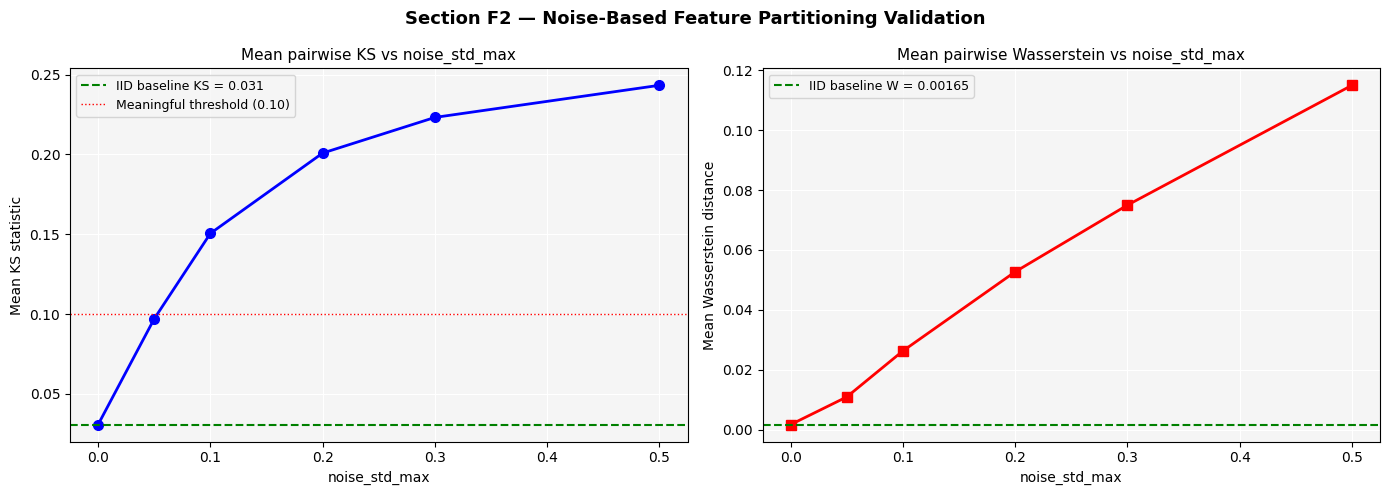


Recommended noise_std_max for meaningful feature Non-IID: 0.05
  (first level where KS ≥ 0.061 = 2× IID baseline)


In [49]:
# ---- F2: Noise-based partitioning ----
# Sweep noise_std to quantify distribution shift in feature space.
# For each noise level, simulate what the feature distributions would look
# like after adding Gaussian noise and measure KS / Wasserstein shift.

NOISE_STDS = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]

noise_results = []
for noise_max in NOISE_STDS:
    parts = NoiseFeaturePartitioner(
        n_partitions=N_PARTIES, noise_std_min=0.0, noise_std_max=noise_max, seed=42
    ).partition(df)

    # Simulate the noise effect on feature statistics:
    # Adding N(0, σ) to feature maps shifts channel_mean by ~0 but increases channel_std.
    # The distribution of channel_mean itself shifts because samples
    # with different original distributions receive different noise levels.
    # The KS between the nosiest (party n-1) and the cleanest (party 0) captures this.
    assigned_stds = [p['noise_std'].iloc[0] for p in parts]

    # Build noised feature distributions per party
    rng_n = np.random.default_rng(1)
    noised_parts = []
    for p, sigma in zip(parts, assigned_stds):
        p2 = p.copy()
        for col in [f'{ch}_mean' for ch in CHANNEL_NAMES]:
            # Noise on the map mean: noise to mean is 0 in expectation,
            # but noise to per-pixel values raises channel_mean by ~0 and std by sigma.
            # Use sigma as a spread multiplier on the distribution of means.
            p2[col] = np.clip(p2[col].values + rng_n.normal(0, sigma, len(p2)), 0, None)
        noised_parts.append(p2)

    ks, wass, _ = pairwise_ks_wasserstein(noised_parts, CHANNEL_NAMES)
    noise_results.append({
        'noise_std_max': noise_max,
        'mean_ks': ks,
        'mean_wass': wass,
        'assigned_stds': assigned_stds,
    })

noise_df = pd.DataFrame(noise_results)
print('Noise partitioning sweep:')
print(noise_df[['noise_std_max','mean_ks','mean_wass']].to_string(index=False))

# IID baseline KS for reference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section F2 — Noise-Based Feature Partitioning Validation',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(noise_df['noise_std_max'], noise_df['mean_ks'], 'bo-', linewidth=2, markersize=7)
ax.axhline(iid_ks, color='green', linestyle='--', linewidth=1.5,
           label=f'IID baseline KS = {iid_ks:.3f}')
ax.axhline(0.10, color='red', linestyle=':', linewidth=1, label='Meaningful threshold (0.10)')
ax.set_title('Mean pairwise KS vs noise_std_max')
ax.set_xlabel('noise_std_max')
ax.set_ylabel('Mean KS statistic')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(noise_df['noise_std_max'], noise_df['mean_wass'], 'rs-', linewidth=2, markersize=7)
ax.axhline(iid_wass, color='green', linestyle='--', linewidth=1.5,
           label=f'IID baseline W = {iid_wass:.5f}')
ax.set_title('Mean pairwise Wasserstein vs noise_std_max')
ax.set_xlabel('noise_std_max')
ax.set_ylabel('Mean Wasserstein distance')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Find the noise_std_max where KS first exceeds 2× IID baseline
target = 2.0 * iid_ks if iid_ks > 0 else 0.05
above_target = noise_df[noise_df['mean_ks'] >= target]
if not above_target.empty:
    rec_noise = above_target.iloc[0]['noise_std_max']
    print(f'\nRecommended noise_std_max for meaningful feature Non-IID: {rec_noise}')
    print(f'  (first level where KS ≥ {target:.3f} = 2× IID baseline)')
else:
    print(f'\nKS never reaches 2× IID baseline in the tested range; try higher noise values.')

Synthetic partition sizes: [3221, 3046, 1155, 1310, 1132, 378]
Synthetic mean pairwise KS:          0.1561
Synthetic mean pairwise Wasserstein: 0.011676

KS ratio vs IID baseline: 5.1×


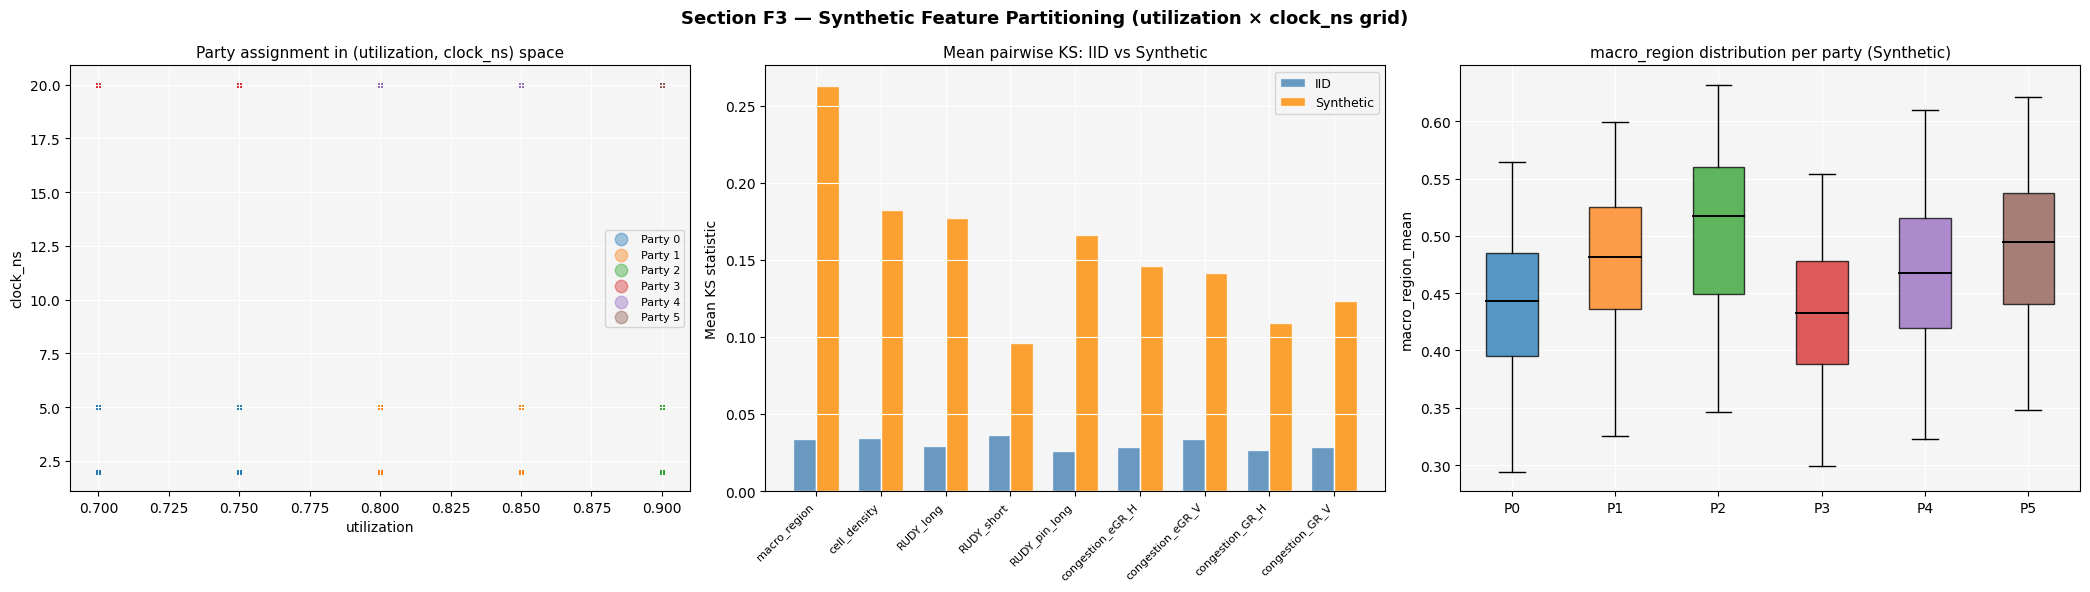

In [50]:
# ---- F3: Synthetic feature partitioning (utilization × clock_ns grid) ----
synth_parts = SyntheticFeaturePartitioner(
    n_partitions=N_PARTIES,
    feature_col_x='utilization',
    feature_col_y='clock_ns',
    seed=42,
).partition(df)

synth_sizes = [len(p) for p in synth_parts]
synth_ks, synth_wass, synth_per_ch = pairwise_ks_wasserstein(synth_parts, CHANNEL_NAMES)

print(f'Synthetic partition sizes: {synth_sizes}')
print(f'Synthetic mean pairwise KS:          {synth_ks:.4f}')
print(f'Synthetic mean pairwise Wasserstein: {synth_wass:.6f}')
print(f'\nKS ratio vs IID baseline: {synth_ks / (iid_ks + 1e-9):.1f}×')

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Section F3 — Synthetic Feature Partitioning (utilization × clock_ns grid)',
             fontsize=13, fontweight='bold')

# Feature-space scatter with party assignment
ax = axes[0]
cmap10 = mcm.get_cmap('tab10')
for i, p in enumerate(synth_parts):
    ax.scatter(p['utilization'], p['clock_ns'],
               s=5, alpha=0.4, color=cmap10(i/10), label=f'Party {i}')
ax.set_xlabel('utilization')
ax.set_ylabel('clock_ns')
ax.set_title('Party assignment in (utilization, clock_ns) space')
ax.legend(fontsize=8, markerscale=4)

# Per-channel KS comparison: IID vs Synthetic
ax = axes[1]
x = np.arange(N_CHANNELS)
w = 0.35
iid_ks_vals   = [np.mean(iid_per_ch[ch])   if iid_per_ch[ch]   else 0 for ch in CHANNEL_NAMES]
synth_ks_vals = [np.mean(synth_per_ch[ch]) if synth_per_ch[ch] else 0 for ch in CHANNEL_NAMES]
ax.bar(x - w/2, iid_ks_vals,   width=w, label='IID',       color='steelblue', alpha=0.8, edgecolor='white')
ax.bar(x + w/2, synth_ks_vals, width=w, label='Synthetic', color='darkorange',alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_title('Mean pairwise KS: IID vs Synthetic')
ax.set_ylabel('Mean KS statistic')
ax.legend(fontsize=9)

# Box plots of top-variance channel per party
ax = axes[2]
key_ch = top2_channels[0]
key_col = f'{key_ch}_mean'
data_synth = [p[key_col].values for p in synth_parts]
bp = ax.boxplot(data_synth, patch_artist=True, notch=False,
                medianprops={'color':'black','linewidth':1.4},
                flierprops={'marker':'.','markersize':2,'alpha':0.3})
for patch, i in zip(bp['boxes'], range(N_PARTIES)):
    patch.set_facecolor(cmap10(i/10))
    patch.set_alpha(0.75)
ax.set_xticks(range(1, N_PARTIES+1))
ax.set_xticklabels([f'P{i}' for i in range(N_PARTIES)])
ax.set_title(f'{key_ch} distribution per party (Synthetic)')
ax.set_ylabel(f'{key_ch}_mean')

plt.tight_layout()
plt.show()

Grid axis comparison:
     axis_x      axis_y  mean_ks  mean_wass
        IID  (baseline)  0.03071   0.001646
      Noise      (best)  0.09701   0.010886
utilization    clock_ns  0.15605   0.011676
utilization macro_count  0.17927   0.013730
   clock_ns macro_count  0.11811   0.008577


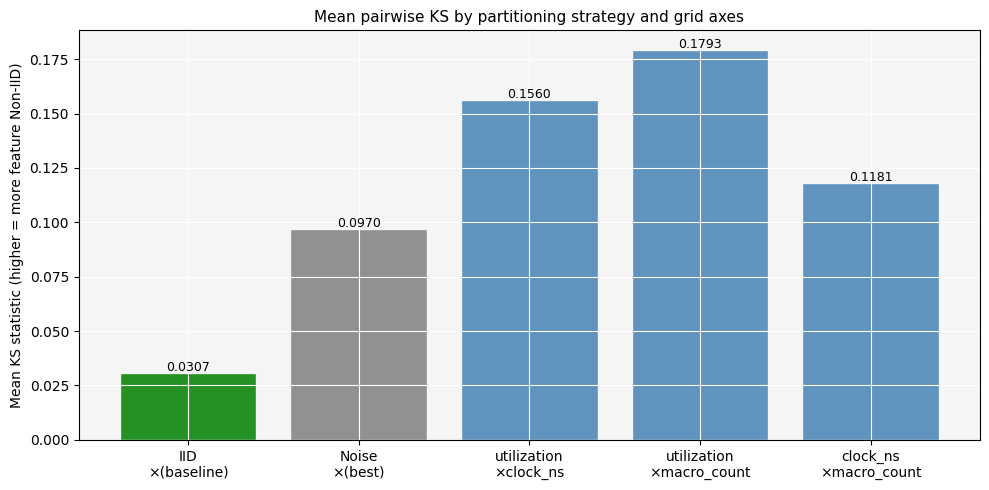

In [51]:
# ---- F4: Alternative synthetic axes — validate other grid choices ----
# Test multiple (x, y) axis combinations to find the pair that maximises KS skew

AXIS_PAIRS = [
    ('utilization', 'clock_ns'),
    ('utilization', 'macro_count'),
    ('clock_ns',    'macro_count'),
]

# macro_count is categorical: encode it numerically for the partitioner
df_enc = df.copy()
df_enc['macro_count_num'] = df_enc['macro_count'].astype(float)

axis_results = []
for x_col, y_col in AXIS_PAIRS:
    x_real = x_col if x_col in df_enc.columns else x_col
    y_real = y_col if y_col != 'macro_count' else 'macro_count_num'
    try:
        parts_ax = SyntheticFeaturePartitioner(
            n_partitions=N_PARTIES,
            feature_col_x=x_real,
            feature_col_y=y_real,
            seed=42,
        ).partition(df_enc)
        ks_ax, wass_ax, _ = pairwise_ks_wasserstein(parts_ax, CHANNEL_NAMES)
        axis_results.append({
            'axis_x': x_col, 'axis_y': y_col,
            'mean_ks': round(ks_ax, 5),
            'mean_wass': round(wass_ax, 6),
            'sizes': [len(p) for p in parts_ax],
        })
    except Exception as e:
        axis_results.append({'axis_x': x_col, 'axis_y': y_col, 'error': str(e)})

# Add IID and best noise for comparison
if not above_target.empty:
    best_noise_ks = float(above_target.iloc[0]['mean_ks'])
    best_noise_wass = float(above_target.iloc[0]['mean_wass'])
else:
    best_noise_ks = noise_df['mean_ks'].max()
    best_noise_wass = noise_df['mean_wass'].max()

axis_results = [
    {'axis_x': 'IID', 'axis_y': '(baseline)', 'mean_ks': round(iid_ks,5), 'mean_wass': round(iid_wass,6), 'sizes': iid_sizes},
    {'axis_x': 'Noise', 'axis_y': '(best)', 'mean_ks': round(best_noise_ks,5), 'mean_wass': round(best_noise_wass,6), 'sizes': ['-']*N_PARTIES},
] + axis_results

axis_df = pd.DataFrame(axis_results)
print('Grid axis comparison:')
print(axis_df[['axis_x','axis_y','mean_ks','mean_wass']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f'{r["axis_x"]}\n×{r["axis_y"]}' for r in axis_results]
ks_vals = [r.get('mean_ks', 0) for r in axis_results]
colors  = ['green' if l.startswith('IID') else 'gray' if l.startswith('Noise')
           else 'steelblue' for l in labels]
bars = ax.bar(labels, ks_vals, color=colors, alpha=0.85, edgecolor='white')
ax.set_title('Mean pairwise KS by partitioning strategy and grid axes')
ax.set_ylabel('Mean KS statistic (higher = more feature Non-IID)')
for bar, v in zip(bars, ks_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section G — Summary: Data-Driven Partitioning Recommendations

Collects all measurements into a final decision table.

In [52]:
print('=' * 70)
print('FEATURE-BASED PARTITIONING — DATA-DRIVEN SUMMARY')
print('=' * 70)

print()
print('1. DESIGN PARAMETER BALANCE')
for col in CAT_COLS:
    vc = df_meta[col].value_counts()
    balance = vc.min() / vc.max()
    verdict = 'OK' if balance > 0.5 else 'IMBALANCED'
    print(f'   {col:<25s}: balance={balance:.3f}  [{verdict}]')

print()
print('2. BEST METADATA PREDICTORS OF FEATURE DISTRIBUTIONS')
r2_items = sorted(r2_scores.items(), key=lambda x: -x[1])
for col, r2 in r2_items[:5]:
    strength = 'strong' if r2 > 0.3 else 'moderate' if r2 > 0.1 else 'weak'
    print(f'   {col:<30s}: R²={r2:.3f}  [{strength} predictor]')

print()
print('3. PCA STRUCTURE')
print(f'   PCs for 90% variance: {n_for_90} out of {len(explained)}')
print(f'   PC1 driven by: {"utilization" if abs(r_util_pc1) > abs(r_clock_pc1) else "clock_ns"}')
print(f'     r(utilization, PC1) = {r_util_pc1:.3f}')
print(f'     r(clock_ns,    PC1) = {r_clock_pc1:.3f}')

print()
print('4. PARTITIONING STRATEGY FEATURE NON-IID SCORES')
print(f'   {"Strategy":<35s}  {"Mean KS":>9s}  {"×IID":>7s}')
strategies = [
    ('IID (baseline)',             iid_ks),
    ('Noise (best)',               best_noise_ks),
    ('Synthetic util×clock',       synth_ks),
]
for name, ks in strategies:
    ratio = ks / (iid_ks + 1e-9)
    verdict = 'BASELINE' if name.startswith('IID') else (
        'HIGH Non-IID' if ratio > 5 else 'MODERATE' if ratio > 2 else 'LOW'
    )
    print(f'   {name:<35s}  {ks:>9.4f}  {ratio:>6.1f}×  [{verdict}]')

print()
print('5. RECOMMENDED CONFIGURATION')
best_axis = axis_df.dropna(subset=['mean_ks']).iloc[
    axis_df.dropna(subset=['mean_ks'])['mean_ks'].astype(float).argmax()
]
print(f'   Best Synthetic grid axes: {best_axis["axis_x"]} × {best_axis["axis_y"]}')
print(f'     → Mean KS = {best_axis["mean_ks"]:.4f}')
if not above_target.empty:
    print(f'   Recommended noise_std_max for meaningful Non-IID: {rec_noise}')
else:
    print('   Noise-based: test higher noise_std values if stronger Non-IID is needed')
print()
print('   For Feature-based Non-IID:')
print('     Use SyntheticFeaturePartitioner with the best axis pair above.')
print('     Noise-based is a lighter alternative when only mild feature skew is needed.')
print('=' * 70)

FEATURE-BASED PARTITIONING — DATA-DRIVEN SUMMARY

1. DESIGN PARAMETER BALANCE
   design_name              : balance=0.549  [OK]
   macro_count              : balance=0.800  [OK]
   macro_placement          : balance=0.206  [IMBALANCED]
   power_mesh               : balance=0.964  [OK]
   filler_insertion         : balance=0.749  [OK]

2. BEST METADATA PREDICTORS OF FEATURE DISTRIBUTIONS
   macro_region_mean             : R²=0.152  [moderate predictor]
   cell_density_mean             : R²=0.060  [weak predictor]
   RUDY_long_mean                : R²=0.054  [weak predictor]
   RUDY_pin_long_mean            : R²=0.038  [weak predictor]
   congestion_eGR_H_mean         : R²=0.035  [weak predictor]

3. PCA STRUCTURE
   PCs for 90% variance: 11 out of 10
   PC1 driven by: utilization
     r(utilization, PC1) = 0.141
     r(clock_ns,    PC1) = -0.086

4. PARTITIONING STRATEGY FEATURE NON-IID SCORES
   Strategy                               Mean KS     ×IID
   IID (baseline)                  

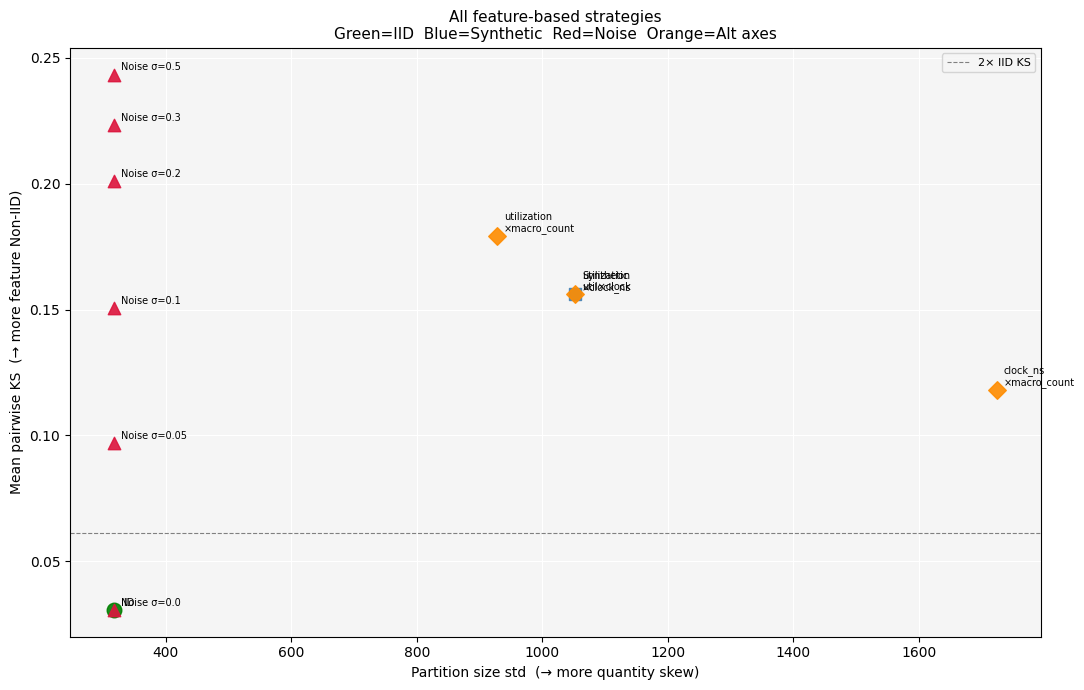

In [53]:
# Final comparison: KS skew vs size std for all strategies
summary_pts = [
    {'label': 'IID',            'ks': iid_ks,        'size_std': np.std(iid_sizes),   'color':'green',     'marker':'o'},
    {'label': 'Synthetic\nutil×clock', 'ks': synth_ks, 'size_std': np.std(synth_sizes), 'color':'steelblue', 'marker':'s'},
]

for row in axis_results[2:]:  # additional axis pairs
    if 'mean_ks' in row and isinstance(row.get('sizes'), list) and row['sizes'] and row['sizes'][0] != '-':
        summary_pts.append({
            'label': f"{row['axis_x']}\n×{row['axis_y']}",
            'ks': row['mean_ks'],
            'size_std': np.std(row['sizes']),
            'color': 'darkorange',
            'marker': 'D',
        })

for nrow in noise_df.itertuples():
    summary_pts.append({
        'label': f'Noise σ={nrow.noise_std_max}',
        'ks': nrow.mean_ks,
        'size_std': np.std(iid_sizes),  # noise doesn't change sizes
        'color': 'crimson',
        'marker': '^',
    })

fig, ax = plt.subplots(figsize=(11, 7))
for pt in summary_pts:
    ax.scatter(pt['size_std'], pt['ks'],
               s=110 if pt['marker']=='o' else 80,
               color=pt['color'], marker=pt['marker'], zorder=5, alpha=0.9)
    ax.annotate(pt['label'], (pt['size_std'], pt['ks']),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.set_xlabel('Partition size std  (→ more quantity skew)')
ax.set_ylabel('Mean pairwise KS  (→ more feature Non-IID)')
ax.set_title('All feature-based strategies\nGreen=IID  Blue=Synthetic  Red=Noise  Orange=Alt axes')
ax.axhline(iid_ks * 2, color='grey', linestyle='--', linewidth=0.8, label='2× IID KS')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()